### Nhập thư viện 

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


### Đọc dataset 

In [70]:
data = pd.read_csv("diabetes_prediction_data.csv",delimiter=';')
print("Kích thước dữ liệu:", data.shape)
data.info()
data.describe().T


Kích thước dữ liệu: (100000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


### 5 dòng đầu của dữ liệu 

In [71]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### Tách nhãn ra khỏi dữ liệu (diabetes)

In [72]:
X = data.drop("diabetes", axis=1)
y = data["diabetes"]

### Xác định cột dạng chuỗi và dùng phương pháp OneHotEncoder

In [73]:
categorical_cols = ['gender',"smoking_history"]         # các cột cần OneHotEncoder
numeric_cols = [col for col in X.columns if col not in categorical_cols]
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),  
        ('num', StandardScaler(), numeric_cols)
    ]
)

### Chia tập train và test

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Tối ưu mô hình bằng GridSearchCV 
+ do  dữ liệu quá lớn máy không thể chạy được nên bỏ qua dòng code 

In [75]:
#from sklearn.pipeline import Pipeline
#from sklearn.model_selection import GridSearchCV

# Pipeline = (preprocess → SVC)
#pipe = Pipeline(steps=[
#    ('preprocess', preprocess),
#    ('svm', SVC())
#])

## Tham số SVC phải viết theo dạng: svm__parameter
#param_grid = {
#    "svm__C": [0.1, 1, 10],
#    "svm__gamma": ["scale", "auto", 0.01, 0.001],
#    "svm__kernel": ["rbf", "poly", "linear"]
#}

#grid = GridSearchCV(
#    pipe,
#    param_grid,
#    cv=5,
#    scoring="accuracy",
#    n_jobs=-1
#)

#grid.fit(X_train, y_train)

#print("Best parameters:", grid.best_params_)
#print("Best CV Accuracy:", grid.best_score_)
#best_model = grid.best_estimator_


### Scaling dữ liệu 

In [76]:
X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

### Xây dựng mô hình SVM

In [77]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale")

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)


### Thời gian chạy 31,5 giây 

### Đánh giá mô hình 

In [ ]:
# code đánh giá mô hình của tối ưu hóa bằng GridSearchCV
#y_pred = best_model.predict(X_test)

#print("\nAccuracy:", accuracy_score(y_test, y_pred))

#print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Accuracy: 0.96515

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.97      0.61      0.75      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.80      0.86     20000
weighted avg       0.97      0.97      0.96     20000


Confusion Matrix:
[[18270    30]
 [  667  1033]]


### Vẽ Confusion Matrix bằng seaborn

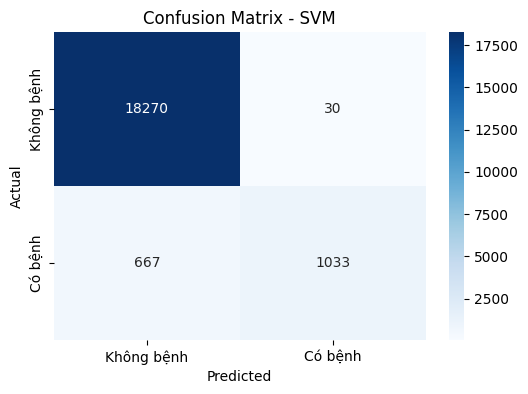

In [80]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Không bệnh", "Có bệnh"],
            yticklabels=["Không bệnh", "Có bệnh"])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

###  Nhận xét 

### Accuracy tổng thể
- Accuracy = 0.96515 (~96.5%) → mô hình dự đoán tổng thể **rất chính xác**.
- Weighted avg F1-score cũng cao (~0.96) nhờ số lượng mẫu lớp 0 rất lớn.

### Nhãn 1 (minority) bị ảnh hưởng
- Recall lớp 1 = 0.61 → chỉ **61% các mẫu thực sự thuộc lớp 1 được nhận diện đúng**.
- Precision lớp 1 = 0.97 → hầu hết dự đoán là lớp 1 đều đúng, nhưng số lượng dự đoán ít hơn thực tế.
- F1-score lớp 1 = 0.75 → thấp hơn nhiều so với lớp 0 (0.98), phản ánh **dataset imbalanced** (18300 mẫu lớp 0, 1700 mẫu lớp 1).

### Confusion Matrix
[[18270 30]

[ 667 1033]]
- Hàng đầu: lớp 0 → 18270 đúng, 30 nhầm sang lớp 1  
- Hàng thứ hai: lớp 1 → 1033 đúng, 667 nhầm sang lớp 0  
→ Mô hình **dự đoán nhãn ít (1) kém hơn** so với nhãn nhiều (0).

---

### Kết luận
- Accuracy cao **nhưng không phản ánh đầy đủ hiệu suất với nhãn ít** → nên dùng thêm **balanced accuracy**, **roc_auc** để đánh giá công bằng hơn.  

### 🔹 Gợi ý cải thiện

###  Dùng balanced accuracy hoặc F1-score macro
```python
from sklearn.metrics import balanced_accuracy_score, f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1-score macro:", f1_score(y_test, y_pred, average='macro'))


### Kết thúc 
